In [43]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from src import get_singular_values, marchenko_pastur_pdf, get_layer_from_checkpoint, run_spectral_analysis, get_layer_fingerprint
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

HT32_PATH = Path("training_runs/mlp32_mnist/HT_alpha_1.2/GeneralMLP_LR0.001_BS128_20260222_113516_s0")
GAUSS32_PATH = Path("training_runs/mlp32_mnist/Gaussian_Baseline/GeneralMLP_LR0.001_BS128_20260222_113641_s0")
HT64_PATH = Path("training_runs/mlp64_mnist/HT_alpha_1.2/GeneralMLP_LR0.001_BS128_20260222_112717_s0")
GAUSS64_PATH = Path("training_runs/mlp64_mnist/Gaussian_Baseline/GeneralMLP_LR0.001_BS128_20260222_112842_s0")
HT128_PATH = Path("training_runs/mlp128_mnist/HT_alpha_1.2/GeneralMLP_LR0.001_BS128_20260222_111642_s0")
GAUSS128_PATH = Path("training_runs/mlp128_mnist/Gaussian_Baseline/GeneralMLP_LR0.001_BS128_20260222_111809_s0")
HT784_PATH = Path("training_runs/mlp784_mnist/HT_alpha_1.2/GeneralMLP_LR0.001_BS128_20260221_130323_s0")
GAUSS784_PATH = Path("training_runs/mlp784_mnist/Gaussian_Baseline/GeneralMLP_LR0.001_BS128_20260221_130451_s0")

<>:38: SyntaxWarning: invalid escape sequence '\l'
<>:42: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\l'
<>:42: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_84104/1441653795.py:38: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('Eigenvalue $\lambda$')
/tmp/ipykernel_84104/1441653795.py:42: SyntaxWarning: invalid escape sequence '\l'
  axes[0].set_ylabel('Log Probability Density $P(\lambda)$')


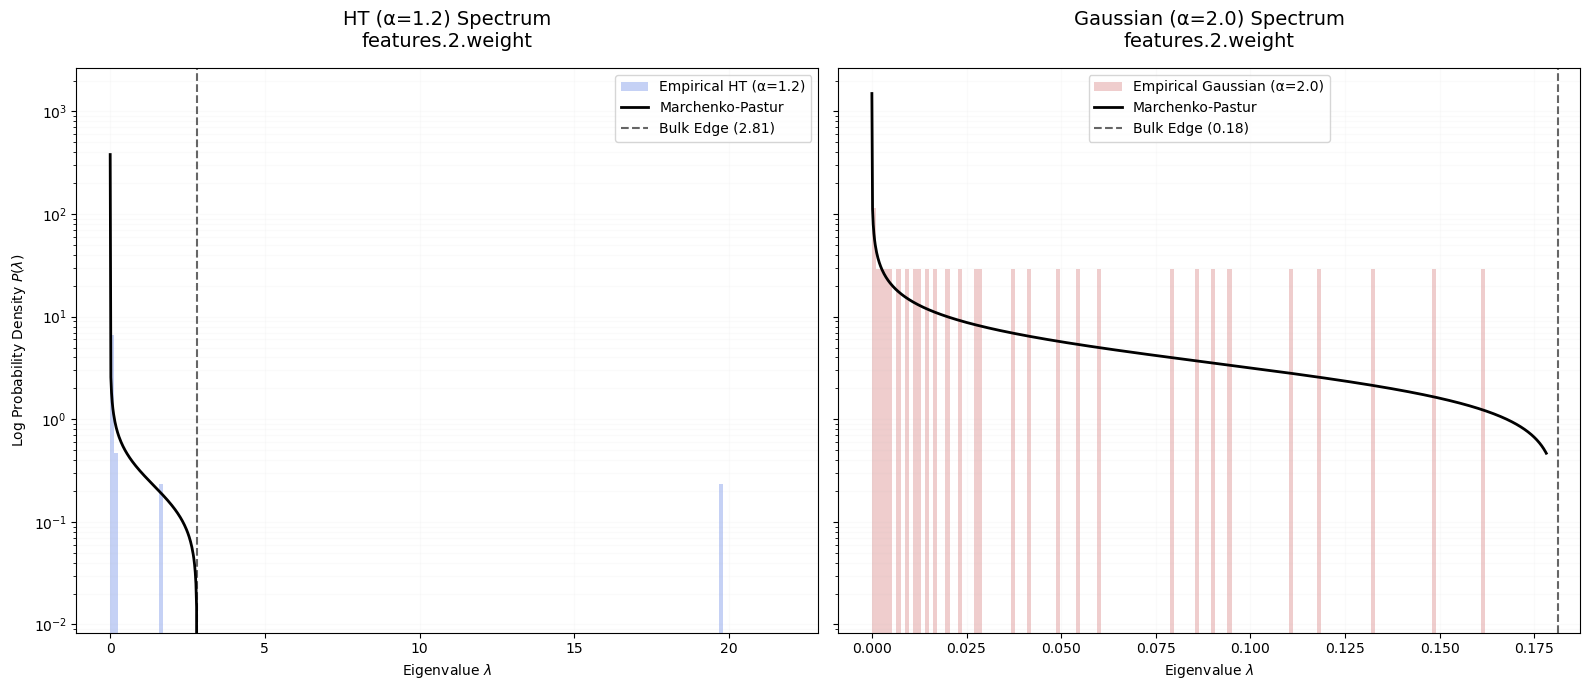

In [18]:
# 1. Config & Paths
LAYER_KEY = 'features.2.weight'

# 2. Direct Extraction using verified functions
W_ht = get_layer_from_checkpoint(HT32_PATH / "final_model.pth", LAYER_KEY)
W_ga = get_layer_from_checkpoint(GAUSS32_PATH / "final_model.pth", LAYER_KEY)

# get_singular_values handles λ = s^2 / M internally
evs_ht = get_singular_values(W_ht)
evs_ga = get_singular_values(W_ga)

# 3. Combined Figure
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
data_configs = [
    (evs_ht, W_ht.shape, 'HT (α=1.2)', 'royalblue'),
    (evs_ga, W_ga.shape, 'Gaussian (α=2.0)', 'indianred')
]

for i, (evs, (N, M), label, color) in enumerate(data_configs):
    ax = axes[i]
    Q = N / M
    sigma_est = np.sqrt(np.mean(evs))

    # Empirical Density
    ax.hist(evs, bins=150, density=True, alpha=0.3, color=color, label=f'Empirical {label}')

    # Theoretical MP Law
    x_range = np.linspace(1e-6, np.max(evs) * 1.1, 1000)
    pdf, _, l_max = marchenko_pastur_pdf(x_range, Q, sigma=sigma_est)
    ax.plot(x_range, pdf, color='black', lw=2, label='Marchenko-Pastur')

    # Bulk Edge Annotation
    ax.axvline(l_max, color='black', linestyle='--', alpha=0.6, label=f'Bulk Edge ({l_max:.2f})')

    # Aesthetics
    ax.set_yscale('log')
    ax.set_title(f"{label} Spectrum\n{LAYER_KEY}", fontsize=14, pad=15)
    ax.set_xlabel('Eigenvalue $\lambda$')
    ax.grid(True, which="both", ls="-", alpha=0.05)
    ax.legend(frameon=True)

axes[0].set_ylabel('Log Probability Density $P(\lambda)$')
plt.tight_layout()
plt.show()

In [53]:
LAYER_KEY = 'features.2.weight'
# Automatically detect available checkpoints
EPOCHS = sorted([int(p.stem.split('_')[-1]) for p in (HT32_PATH / "checkpoints").glob("weights_epoch_*.pth")])

# --- PRE-SCAN FOR STATIC X-AXIS ---
print("Scanning checkpoints for global spectral bounds...")
global_max_lambda = 0
for epoch in EPOCHS:
    path = HT32_PATH / "checkpoints" / f"weights_epoch_{epoch}.pth"
    # Use verified singular value extraction (includes 1/M scaling)
    S_vals = get_singular_values(get_layer_from_checkpoint(path, LAYER_KEY))
    global_max_lambda = max(global_max_lambda, np.max(S_vals))

# 2. Initialize Persistent Figure
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_yscale('log')
ax.set_xlim(0, global_max_lambda * 1.05) # Static X-axis
ax.set_ylim(1e-3, 1e3)
ax.grid(True, which='both', alpha=0.05)

# Artists
hist_container = []
theory_line, = ax.plot([], [], 'r-', lw=2, label='MP Bulk Theory')
bulk_edge_line = ax.axvline(0, color='red', linestyle='--', alpha=0.5, label='Bulk Edge')

def update(epoch):
    """Update function for FuncAnimation using strict internal logic."""
    path = HT32_PATH / "checkpoints" / f"weights_epoch_{epoch}.pth"
    W = get_layer_from_checkpoint(path, LAYER_KEY)
    evs = get_singular_values(W) # S^2 / M

    # 1. Update Histogram
    global hist_container
    for patch in hist_container:
        patch.remove()

    counts, bins, hist_container = ax.hist(evs, bins=100, density=True,
                                            alpha=0.3, color='royalblue')

    # 2. Update Theoretical MP Law
    Q = W.shape[0] / W.shape[1]
    sigma_est = np.sqrt(np.mean(evs))
    x_range = np.linspace(1e-4, global_max_lambda * 1.05, 500)
    pdf, _, l_max = marchenko_pastur_pdf(x_range, Q, sigma=sigma_est)

    theory_line.set_data(x_range, pdf)
    bulk_edge_line.set_xdata([l_max])

    ax.set_title(f"Spectral Evolution: {LAYER_KEY} (Static Axis)\nEpoch {epoch} | $\\alpha=1.2$")
    return theory_line, bulk_edge_line, *hist_container

# 3. Build and Display
ani = FuncAnimation(fig, update, frames=EPOCHS, blit=False)
plt.close() # Prevent extra static plot
HTML(ani.to_jshtml())

Scanning checkpoints for global spectral bounds...


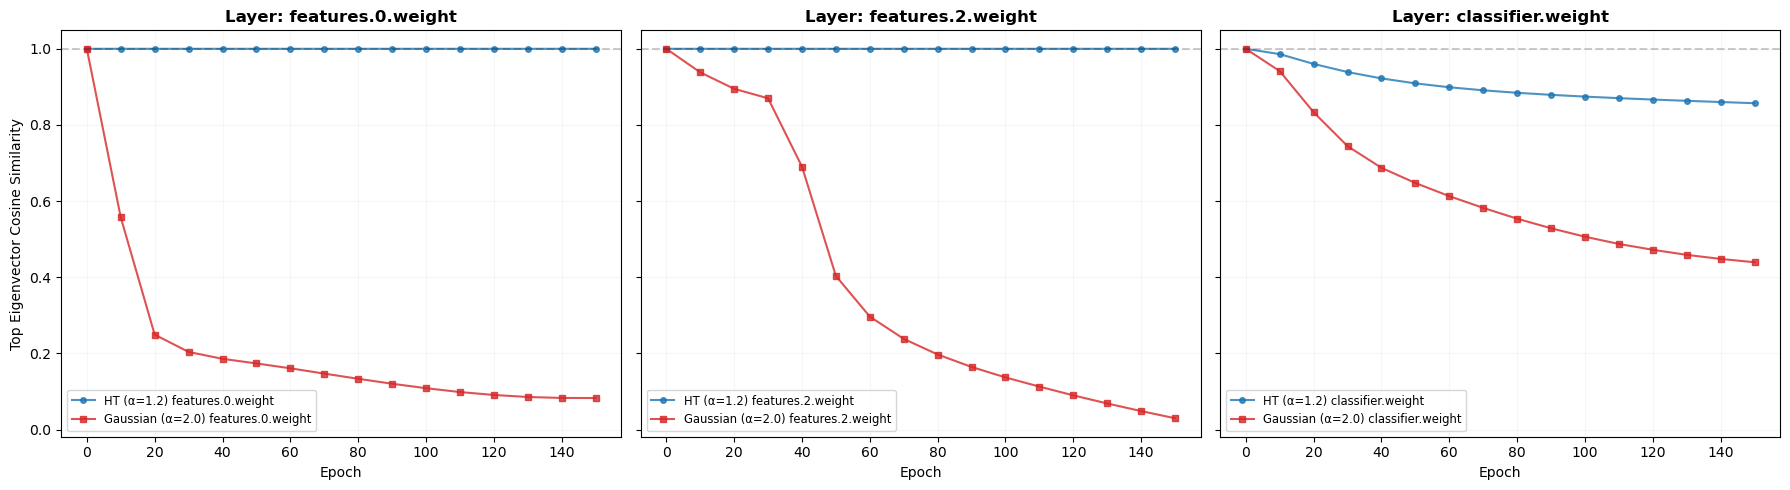

In [36]:
LAYERS = ['features.0.weight', 'features.2.weight', 'classifier.weight']
EPOCHS = range(0, 160, 10)

def get_layer_rotations(run_dir, layers, epochs):
    """Calculates cosine similarity between the top singular vector at epoch 0 vs. t."""
    results = {layer: [] for layer in layers}

    for layer in layers:
        # Load Reference State (Epoch 0) using strict analysis tools
        W0 = get_layer_from_checkpoint(run_dir / "checkpoints/weights_epoch_0.pth", layer)
        _, _, Vt0 = torch.svd(W0)
        v0 = Vt0[:, 0] # Principal right-singular vector

        for epoch in epochs:
            ckpt_path = run_dir / "checkpoints" / f"weights_epoch_{epoch}.pth"
            if not ckpt_path.exists():
                results[layer].append(None)
                continue

            # Load Target State
            Wt = get_layer_from_checkpoint(ckpt_path, layer)
            _, _, Vtt = torch.svd(Wt)
            vt = Vtt[:, 0]

            # Cosine Similarity (absolute value to ignore phase flips)
            similarity = torch.abs(torch.dot(v0, vt)).item()
            results[layer].append(similarity)

    return results

# 2. Execution
ht_rotations = get_layer_rotations(HT32_PATH, LAYERS, EPOCHS)
ga_rotations = get_layer_rotations(GAUSS32_PATH, LAYERS, EPOCHS)

# 3. Visualization Suite
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
run_styles = [
    (ht_rotations, '#1f77b4', 'o', 'HT (α=1.2)'),
    (ga_rotations, '#d62728', 's', 'Gaussian (α=2.0)')
]

for i, layer in enumerate(LAYERS):
    ax = axes[i]
    for results, color, marker, label in run_styles:
        ax.plot(EPOCHS, results[layer], color=color, marker=marker,
                label=f"{label} {layer}", markersize=4, alpha=0.8)

    ax.axhline(1.0, color='black', alpha=0.2, linestyle='--')
    ax.set_title(f"Layer: {layer}", fontweight='bold')
    ax.set_xlabel("Epoch")
    ax.grid(True, which='both', alpha=0.1)

    if i == 0:
        ax.set_ylabel("Top Eigenvector Cosine Similarity")
    ax.legend(fontsize='small')

plt.tight_layout()
plt.show()

Executing sweep for features.0.weight...
Fast-loading MNIST to cuda...
Starting ablate sweep on features.0.weight for GeneralMLP_LR0.001_BS128_20260221_130323_s0...
  k=0 | Accuracy: 0.9701
  k=1 | Accuracy: 0.9699
  k=2 | Accuracy: 0.9692
  k=3 | Accuracy: 0.9690
  k=4 | Accuracy: 0.9693
  k=5 | Accuracy: 0.9689
  k=6 | Accuracy: 0.9688
  k=7 | Accuracy: 0.9682
  k=8 | Accuracy: 0.9688
  k=9 | Accuracy: 0.9685
  k=10 | Accuracy: 0.9681
Fast-loading MNIST to cuda...
Starting ablate sweep on features.0.weight for GeneralMLP_LR0.001_BS128_20260221_130451_s0...
  k=0 | Accuracy: 0.9718
  k=1 | Accuracy: 0.9512
  k=2 | Accuracy: 0.9324
  k=3 | Accuracy: 0.9292
  k=4 | Accuracy: 0.9338
  k=5 | Accuracy: 0.9335
  k=6 | Accuracy: 0.9273
  k=7 | Accuracy: 0.9237
  k=8 | Accuracy: 0.9182
  k=9 | Accuracy: 0.9115
  k=10 | Accuracy: 0.8942
Executing sweep for features.2.weight...
Fast-loading MNIST to cuda...
Starting ablate sweep on features.2.weight for GeneralMLP_LR0.001_BS128_20260221_130323_

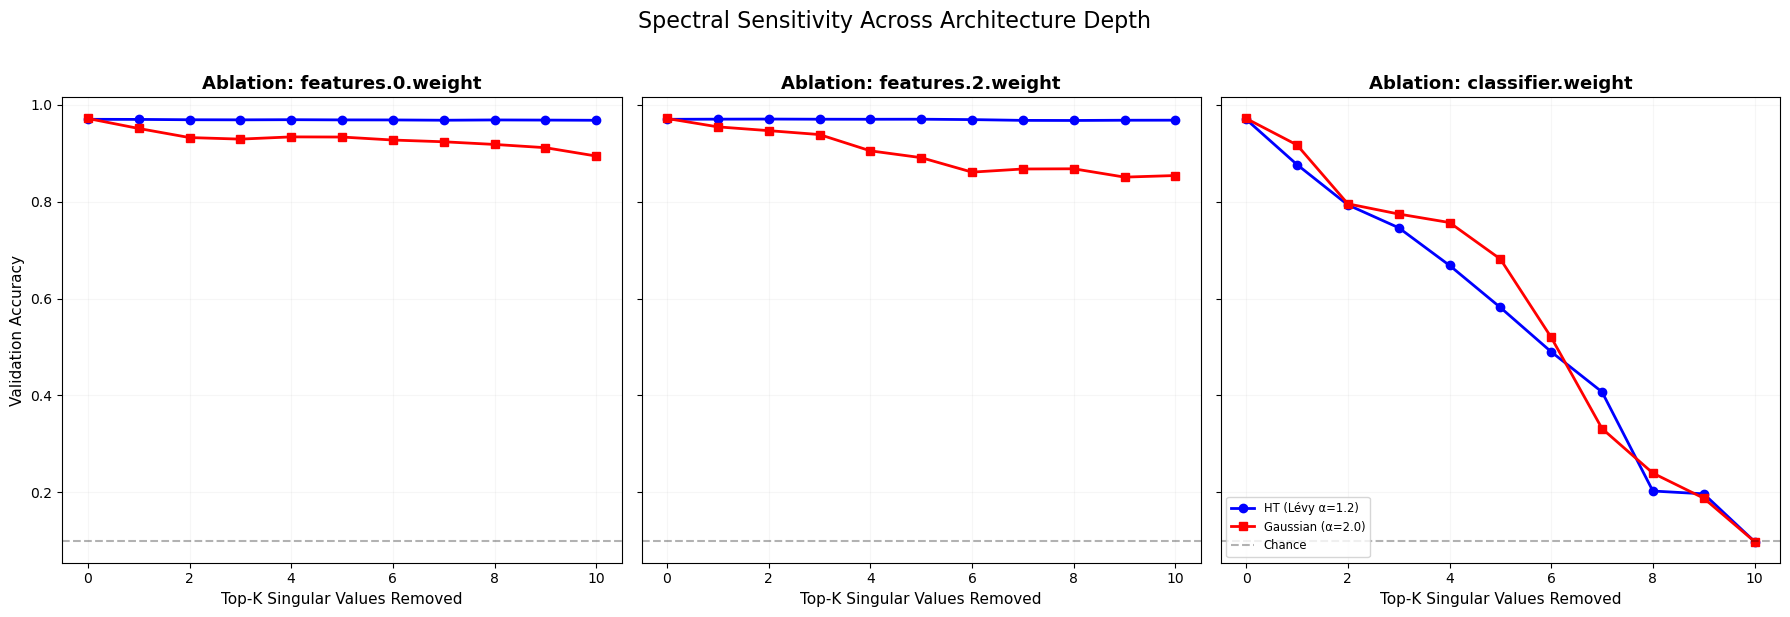

In [49]:
# 1. Paths & Configuration
# Assuming master config is two levels up from the run leaf
CONFIG_PATH = HT784_PATH.parent.parent / "mlp784_mnist.yaml"
LAYERS = ['features.0.weight', 'features.2.weight', 'classifier.weight']
K_VALUES = list(range(0, 11))

# 2. Execution and Plotting Loop
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, layer in enumerate(LAYERS):
    ax = axes[i]
    print(f"Executing sweep for {layer}...")

    # Automated parent wrapper handles data loading and model factory
    ht_raw = run_spectral_analysis(HT784_PATH, CONFIG_PATH, layer, K_VALUES, mode='ablate')
    ga_raw = run_spectral_analysis(GAUSS784_PATH, CONFIG_PATH, layer, K_VALUES, mode='ablate')

    # Extract accuracies from the result dictionaries
    ht_accs = [r['accuracy'] for r in ht_raw]
    ga_accs = [r['accuracy'] for r in ga_raw]

    # Visualization
    ax.plot(K_VALUES, ht_accs, 'b-o', label='HT (Lévy α=1.2)', linewidth=2)
    ax.plot(K_VALUES, ga_accs, 'r-s', label='Gaussian (α=2.0)', linewidth=2)

    # Formatting
    ax.axhline(0.1, color='black', linestyle='--', alpha=0.3, label='Chance')
    ax.set_title(f"Ablation: {layer}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Top-K Singular Values Removed", fontsize=11)
    ax.grid(True, which='both', alpha=0.1)

    if i == 0:
        ax.set_ylabel("Validation Accuracy", fontsize=11)
    if i == 2:
        ax.legend(frameon=True, loc='lower left', fontsize='small')

plt.suptitle("Spectral Sensitivity Across Architecture Depth", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [54]:
def analyze_run(run_path, layers):
    """
    Analyzes a training run by comparing the final state to initialization
    using standardized fingerprinting.
    """
    results = []

    # Checkpoints for comparison to calculate displacement and stability
    init_path = run_path / "checkpoints" / "weights_epoch_0.pth"
    final_path = run_path / "final_model.pth"

    for layer in layers:
        # Strict usage of analysis utilities
        W_init = get_layer_from_checkpoint(init_path, layer)
        W_final = get_layer_from_checkpoint(final_path, layer)

        # Computes IPR, Eff Rank, Displacement, and PR in one pass
        metrics = get_layer_fingerprint(W_init, W_final)
        metrics['layer'] = layer
        results.append(metrics)

    return pd.DataFrame(results)

# 1. Config Paths
LAYERS = ['features.0.weight', 'features.2.weight', 'classifier.weight']

# 2. Execution
ht_df = analyze_run(HT32_PATH, LAYERS)
ga_df = analyze_run(GAUSS32_PATH, LAYERS)

# 3. Output
print("--- Heavy-Tailed (HT) Spectral Fingerprint ---")
print(ht_df[['layer', 'ipr', 'effective_rank', 'displacement', 'participation_ratio']])

print("\n--- Gaussian (GA) Spectral Fingerprint ---")
print(ga_df[['layer', 'ipr', 'effective_rank', 'displacement', 'participation_ratio']])

--- Heavy-Tailed (HT) Spectral Fingerprint ---
               layer       ipr  effective_rank  displacement  \
0  features.0.weight  0.954183        2.861837      0.076957   
1  features.2.weight  0.999206        1.132317      0.117499   
2  classifier.weight  0.304204        5.032941      1.185388   

   participation_ratio  
0             0.431634  
1             0.138754  
2             0.910257  

--- Gaussian (GA) Spectral Fingerprint ---
               layer       ipr  effective_rank  displacement  \
0  features.0.weight  0.003975       21.535532      0.341290   
1  features.2.weight  0.082585        8.955302      0.469573   
2  classifier.weight  0.071470        6.004311      0.860841   

   participation_ratio  
0             0.987577  
1             0.693546  
2             0.942617  
